# Nettoyage des Données d'Accidents 2024

Ce notebook nettoie et prépare les données d'accidents pour le Machine Learning selon les objectifs du projet Data Science 2025-2026.

## Étapes:
1. Chargement des données
2. Suppression des doublons
3. Traitement des valeurs manquantes
4. Nettoyage des colonnes numériques
5. Encodage des variables catégoriques
6. Normalisation des variables numériques
7. Validation et sauvegarde

## 1. Import des librairies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from pathlib import Path
import pickle
import warnings
warnings.filterwarnings('ignore')

# Configuration
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print("Librairies importées")

Librairies importées


## 2. Chargement des données

In [2]:
# Chemins
base_path = Path.cwd().parent
data_path = base_path / 'data' / 'accidents_2024.csv'

# Charger les données
df = pd.read_csv(data_path, sep=';', encoding='latin-1')

print(f"Données chargées: {df.shape[0]:,} lignes, {df.shape[1]} colonnes")
print(f"\nPremières lignes:")
df.head()

Données chargées: 54,402 lignes, 14 colonnes

Premières lignes:


,Num_Acc,Département,Agglomération,Luminosité,Météo (conditions atmos.),Type de collision,Catégorie de route,Régime de circulation,Nombre de voies,État de la surface,Infrastructure,Situation de laccident,Vitesse max autorisée,Gravité (label)
0,"2,02E+11",70,Hors agglomération,Crépuscule / aube,Brouillard / fumée,2 véhicules - frontale,Route départementale,Bidirectionnelle,2 voie(s),Normale,Aucun,Sur chaussée,90 km/h,Blessé hospitalisé
1,"2,02E+11",21,En agglomération,Plein jour,Temps éblouissant,Autre collision,Voie communale,Bidirectionnelle,2 voie(s),Autre,Aucun,Sur chaussée,30 km/h,Blessé hospitalisé
2,"2,02E+11",15,Hors agglomération,Crépuscule / aube,Normale,Autre collision,Voie communale,Bidirectionnelle,2 voie(s),Normale,Aucun,Sur accotement,50 km/h,Blessé hospitalisé
3,"2,02E+11",14,En agglomération,Plein jour,Temps éblouissant,2 véhicules - par le côté,Voie communale,Bidirectionnelle,4 voie(s),Normale,Autres,Sur chaussée,50 km/h,Blessé léger
4,"2,02E+11",13,Hors agglomération,Nuit avec éclairage public allumé,Pluie légère,3 véhicules et + - collisions multiples,Autoroute,Bidirectionnelle,4 voie(s),Mouillée,Aucun,Sur chaussée,50 km/h,Blessé léger


## 3. Exploration initiale

In [3]:
print("Informations sur les données:")
print(df.info())
print(f"\n\nValeurs manquantes:")
missing = df.isnull().sum()
if missing.sum() > 0:
    print(missing[missing > 0])
else:
    print("Pas de valeurs manquantes!")

Informations sur les données:
<class 'pandas.DataFrame'>
RangeIndex: 54402 entries, 0 to 54401
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   Num_Acc                    54402 non-null  str  
 1   Département                54402 non-null  str  
 2   Agglomération              54402 non-null  str  
 3   Luminosité                 54402 non-null  str  
 4   Météo (conditions atmos.)  54391 non-null  str  
 5   Type de collision          54401 non-null  str  
 6   Catégorie de route         54402 non-null  str  
 7   Régime de circulation      54402 non-null  str  
 8   Nombre de voies            54402 non-null  str  
 9   État de la surface         54402 non-null  str  
 10  Infrastructure             54402 non-null  str  
 11  Situation de laccident    54402 non-null  str  
 12  Vitesse max autorisée      54402 non-null  str  
 13  Gravité (label)            54402 non-null  str  
dtypes: 

## 4. Analyse de Num_Acc (identifiant unique)

In [4]:
print(f"Doublons sur Num_Acc: {df['Num_Acc'].duplicated().sum()}")
print(f"Valeurs uniques: {df['Num_Acc'].nunique()}")
print(f"\nPremières Num_Acc:")
print(df['Num_Acc'].head(10))

# Vérifier comment les données sont structurées
print(f"\nExemple d'une vraie observation:")
df[['Num_Acc', 'Département', 'Agglomération', 'Gravité (label)']].head()

Doublons sur Num_Acc: 54401
Valeurs uniques: 1

Premières Num_Acc:
0    2,02E+11
1    2,02E+11
2    2,02E+11
3    2,02E+11
4    2,02E+11
5    2,02E+11
6    2,02E+11
7    2,02E+11
8    2,02E+11
9    2,02E+11
Name: Num_Acc, dtype: str

Exemple d'une vraie observation:


,Num_Acc,Département,Agglomération,Gravité (label)
0,"2,02E+11",70,Hors agglomération,Blessé hospitalisé
1,"2,02E+11",21,En agglomération,Blessé hospitalisé
2,"2,02E+11",15,Hors agglomération,Blessé hospitalisé
3,"2,02E+11",14,En agglomération,Blessé léger
4,"2,02E+11",13,Hors agglomération,Blessé léger


## 5. Nettoyage des données

### 5.1 Suppression des doublons

In [5]:
# Créer une copie pour le nettoyage
df_clean = df.copy()

initial_length = len(df_clean)
df_clean = df_clean.drop_duplicates(keep='first')
duplicates_removed = initial_length - len(df_clean)

print(f"Doublons supprimés: {duplicates_removed}")
print(f"  Lignes restantes: {len(df_clean):,}")

Doublons supprimés: 13221
  Lignes restantes: 41,181


### 5.2 Traitement des valeurs manquantes

In [6]:
print("Analyse des valeurs manquantes:")
missing_info = df_clean.isnull().sum()

if missing_info.sum() > 0:
    for col in missing_info[missing_info > 0].index:
        percentage = (missing_info[col] / len(df_clean)) * 100
        print(f"  - {col}: {missing_info[col]} ({percentage:.2f}%)")
        
    # Traitement
    # Supprimer les lignes avec valeurs manquantes critiques
    critical_cols = [col for col in ['Num_Acc', 'Gravité (label)'] if col in df_clean.columns]
    df_clean = df_clean.dropna(subset=critical_cols)
    
    # Remplir les autres valeurs manquantes
    # Catégories: mode
    for col in df_clean.select_dtypes(include=['object']).columns:
        if df_clean[col].isnull().sum() > 0:
            mode_val = df_clean[col].mode()[0] if not df_clean[col].mode().empty else 'Inconnu'
            df_clean[col].fillna(mode_val, inplace=True)
    
    # Numériques: médiane
    for col in df_clean.select_dtypes(include=['int64', 'float64']).columns:
        if df_clean[col].isnull().sum() > 0:
            df_clean[col].fillna(df_clean[col].median(), inplace=True)
    
    print(f"\nValeurs manquantes traitées")
else:
    print("Pas de valeurs manquantes détectées!")

print(f"\nValeurs manquantes restantes: {df_clean.isnull().sum().sum()}")

Analyse des valeurs manquantes:
  - Météo (conditions atmos.): 11 (0.03%)
  - Type de collision: 1 (0.00%)

Valeurs manquantes traitées

Valeurs manquantes restantes: 12


### 5.3 Nettoyage des colonnes numériques

In [7]:
# Convertir Num_Acc: notation scientifique → entier
if 'Num_Acc' in df_clean.columns:
    df_clean['Num_Acc'] = df_clean['Num_Acc'].astype(str).str.replace(',', '.').astype(float).astype('Int64')
    print(f"Num_Acc converti")

# Convertir Département
if 'Département' in df_clean.columns:
    df_clean['Département'] = pd.to_numeric(df_clean['Département'], errors='coerce').fillna(0).astype('Int32')
    print(f"Département converti")

# Convertir Nombre de voies
if 'Nombre de voies' in df_clean.columns:
    df_clean['Nombre de voies'] = df_clean['Nombre de voies'].astype(str).str.extract(r'(\d+)', expand=False).astype('Int32')
    print(f"Nombre de voies converti")

# Convertir Vitesse max
if 'Vitesse max autorisée' in df_clean.columns:
    df_clean['Vitesse max autorisée'] = df_clean['Vitesse max autorisée'].astype(str).str.extract(r'(\d+)', expand=False).astype('Int32')
    print(f"Vitesse max autorisée convertie")

print(f"\nColonnes numériques nettoyées")

Num_Acc converti
Département converti
Nombre de voies converti
Vitesse max autorisée convertie

Colonnes numériques nettoyées


### 5.4 Standardisation du texte

In [8]:
# Supprimer espaces inutiles dans colonnes texte
for col in df_clean.select_dtypes(include=['object']).columns:
    df_clean[col] = df_clean[col].astype(str).str.strip()

print(f"Colonnes texte standardisées")

Colonnes texte standardisées


## 6. Préparation pour Machine Learning

### 6.1 Encodage des variables catégoriques

In [9]:
# Créer une copie pour ML
df_ml = df_clean.copy()

# Dictionnaire des encodeurs
encoders = {}

# Colonnes catégoriques à encoder
categorical_cols = ['Agglomération', 'Luminosité', 'Météo (conditions atmos.)', 
                    'Type de collision', 'Catégorie de route', 'Régime de circulation',
                    'État de la surface', 'Infrastructure', 'Situation de l\'accident',
                    'Gravité (label)']

print("Encodage des variables catégoriques:")
for col in categorical_cols:
    if col in df_ml.columns:
        le = LabelEncoder()
        df_ml[col] = le.fit_transform(df_ml[col].astype(str))
        encoders[col] = le
        print(f"  {col}: {len(le.classes_)} classes -> {list(le.classes_[:3])}...")

print(f"\n{len(encoders)} variables catégoriques encodées")

Encodage des variables catégoriques:
  Agglomération: 2 classes -> ['En agglomération', 'Hors agglomération']...
  Luminosité: 5 classes -> ['Crépuscule / aube', 'Nuit avec éclairage public allumé', 'Nuit avec éclairage public non allumé']...
  Météo (conditions atmos.): 10 classes -> ['Autre', 'Brouillard / fumée', 'Neige / grêle']...
  Type de collision: 9 classes -> ['2 véhicules - frontale', '2 véhicules - par le côté', '2 véhicules - par l\x92arrière']...
  Catégorie de route: 8 classes -> ['Autoroute', 'Autre', 'Hors réseau public']...
  Régime de circulation: 5 classes -> ['Bidirectionnelle', 'Chaussées séparées', 'Non renseigné']...
  État de la surface: 10 classes -> ['Autre', 'Boue', 'Corps gras / huile']...
  Infrastructure: 11 classes -> ['Aucun', 'Autres', 'Bretelle d\x92échangeur / raccordement']...
  Gravité (label): 3 classes -> ['Blessé hospitalisé', 'Blessé léger', 'Tué']...

9 variables catégoriques encodées


### 6.2 Normalisation des variables numériques

In [10]:
# Variables numériques à normaliser
numeric_cols = ['Département', 'Nombre de voies', 'Vitesse max autorisée']
numeric_cols = [col for col in numeric_cols if col in df_ml.columns]

scaler = StandardScaler()
df_ml[numeric_cols] = scaler.fit_transform(df_ml[numeric_cols])

print(f"Normalisation de {len(numeric_cols)} variables numériques")
for col in numeric_cols:
    print(f"  - {col}: mean={df_ml[col].mean():.6f}, std={df_ml[col].std():.6f}")

Normalisation de 3 variables numériques
  - Département: mean=-0.000000, std=1.000012
  - Nombre de voies: mean=-0.000000, std=1.000013
  - Vitesse max autorisée: mean=-0.000000, std=1.000012


## 7. Validation et rapport final

In [11]:
print("="*60)
print("RAPPORT DE VALIDATION FINAL")
print("="*60)
print(f"\nNombre de lignes: {len(df_ml):,}")
print(f"Nombre de colonnes: {len(df_ml.columns)}")
print(f"Valeurs manquantes: {df_ml.isnull().sum().sum()}")
print(f"\nDistribution de la variable cible (Gravité):")

if 'Gravité (label)' in df_ml.columns:
    # Récupérer les labels originaux pour affichage
    gravity_labels = encoders['Gravité (label)'].inverse_transform(df_ml['Gravité (label)'].unique())
    for i, label in enumerate(sorted(gravity_labels)):
        count = (df_ml['Gravité (label)'] == encoders['Gravité (label)'].transform([label])[0]).sum()
        percentage = (count / len(df_ml)) * 100
        print(f"  - {label}: {count:,} ({percentage:.2f}%)")

print(f"\nTypes de données:")
print(df_ml.dtypes)

RAPPORT DE VALIDATION FINAL

Nombre de lignes: 41,181
Nombre de colonnes: 14
Valeurs manquantes: 2843

Distribution de la variable cible (Gravité):
  - Blessé hospitalisé: 13,572 (32.96%)
  - Blessé léger: 24,619 (59.78%)
  - Tué: 2,990 (7.26%)

Types de données:
Num_Acc                        Int64
Département                  float64
Agglomération                  int64
Luminosité                     int64
Météo (conditions atmos.)      int64
Type de collision              int64
Catégorie de route             int64
Régime de circulation          int64
Nombre de voies              float64
État de la surface             int64
Infrastructure                 int64
Situation de laccident          str
Vitesse max autorisée        float64
Gravité (label)                int64
dtype: object


## 8. Sauvegarde des données nettoyées

In [12]:
# Chemins de sortie
output_clean = base_path / 'data' / 'accidents_2024_cleaned.csv'
output_metadata = base_path / 'data' / 'preprocessing_metadata.pkl'

# Sauvegarder les données nettoyées
df_ml.to_csv(output_clean, sep=';', encoding='utf-8', index=False)
print(f"Données nettoyées sauvegardées: {output_clean}")

# Sauvegarder les métadonnées (encodeurs et scaler)
metadata = {
    'encoders': encoders,
    'scaler': scaler,
    'categorical_columns': categorical_cols,
    'numeric_columns': numeric_cols
}

with open(output_metadata, 'wb') as f:
    pickle.dump(metadata, f)

print(f"Métadonnées sauvegardées: {output_metadata}")
print(f"\nNettoyage terminé avec succès!")

Données nettoyées sauvegardées: /home/younes/Bureau/l3/S2/projet_data/ProjetData/data/accidents_2024_cleaned.csv
Métadonnées sauvegardées: /home/younes/Bureau/l3/S2/projet_data/ProjetData/data/preprocessing_metadata.pkl

Nettoyage terminé avec succès!


## 9. Visualisation des données

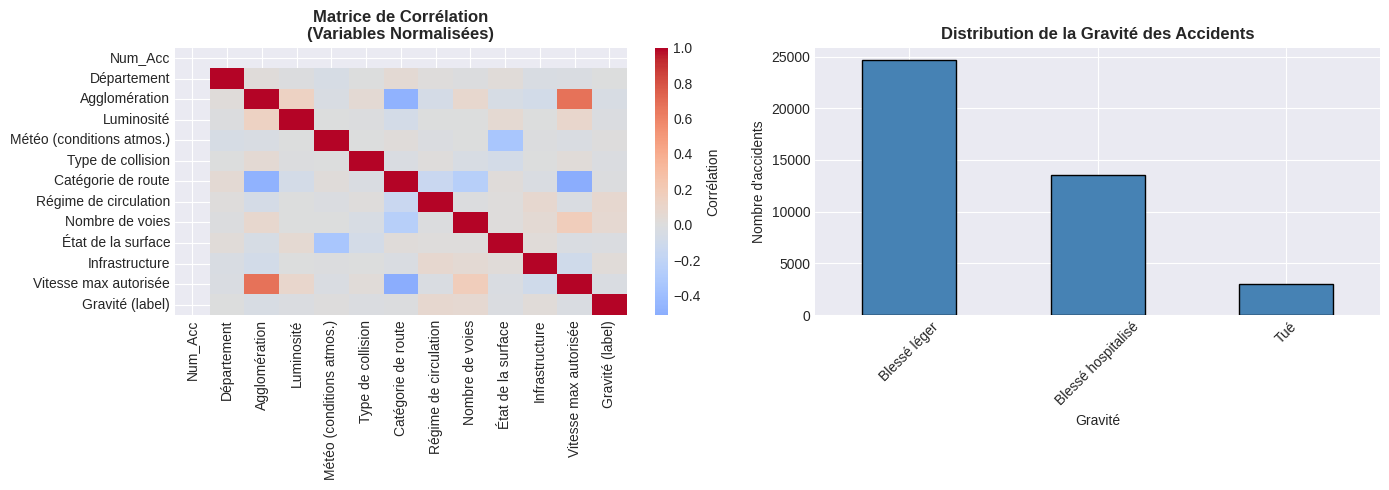

Graphiques générés


In [13]:
# Heatmap de corrélation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matrice de corrélation
correlation_matrix = df_ml.corr(numeric_only=True)
sns.heatmap(correlation_matrix, cmap='coolwarm', center=0, ax=axes[0], cbar_kws={'label': 'Corrélation'})
axes[0].set_title('Matrice de Corrélation\n(Variables Normalisées)', fontsize=12, fontweight='bold')

# Distribution de la gravité
gravity_raw = df_clean['Gravité (label)'].value_counts()
gravity_raw.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title('Distribution de la Gravité des Accidents', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Gravité')
axes[1].set_ylabel('Nombre d\'accidents')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("Graphiques générés")